In [95]:
import zipfile
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image


In [96]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2025-11-07 07:57:07--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.108.207, 192.178.142.207, 142.251.121.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.108.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.2’

pizza_steak.zip.2   100%[===================>] 104.47M   174MB/s    in 0.6s    

2025-11-07 07:57:08 (174 MB/s) - ‘pizza_steak.zip.2’ saved [109540975/109540975]



In [97]:
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

In [98]:
!ls pizza_steak/

test  train


In [99]:
# same as above to call directory
base_dir = "pizza_steak"
print(os.listdir(base_dir))

['test', 'train']


In [100]:
!ls pizza_steak/train/

pizza  steak


In [101]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [102]:
for dirpath, dirnames,filenames in os.walk(base_dir):
  print(f"There area {len(dirnames)} directories and {len(filenames)}) imeges in {dirpath}")

There area 2 directories and 0) imeges in pizza_steak
There area 2 directories and 0) imeges in pizza_steak/test
There area 0 directories and 250) imeges in pizza_steak/test/steak
There area 0 directories and 250) imeges in pizza_steak/test/pizza
There area 2 directories and 0) imeges in pizza_steak/train
There area 0 directories and 750) imeges in pizza_steak/train/steak
There area 0 directories and 750) imeges in pizza_steak/train/pizza


In [103]:
# A function to visualize images
def veiw_ranimag(target_dir,target_class):
  #get a list of all target class images
  target_fol = target_dir + target_class
  ranimg=random.sample(os.listdir(target_fol),1)

  img=mpimg.imread(target_fol + "/" + ranimg[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  print(f"Image shape: {img.shape}")
  return img

Image shape: (512, 512, 3)


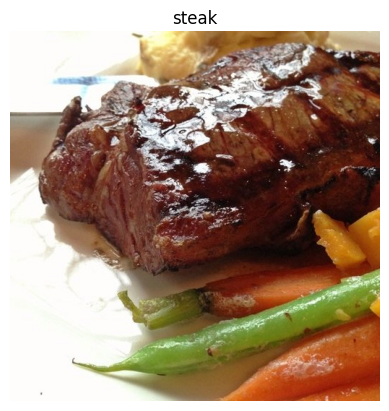

In [104]:
img=veiw_ranimag(target_dir = "pizza_steak/train/",target_class="steak")

array([[[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [211, 200, 172],
        [210, 199, 171],
        [211, 200, 172]],

       [[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [209, 198, 170],
        [209, 198, 170],
        [211, 200, 172]],

       [[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [207, 196, 168],
        [207, 196, 168],
        [209, 198, 170]],

       ...,

       [[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [196, 103,  34],
        [192,  99,  30],
        [186,  93,  24]],

       [[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [195, 100,  32],
        [191,  98,  29],
        [190,  97,  28]],

       [[254, 253, 251],
        [254, 253, 251],
        [254, 253, 251],
        ...,
        [191,  96,  28],
        [193, 100,  31],
        [198, 105,  36]]], dtype=uint8)
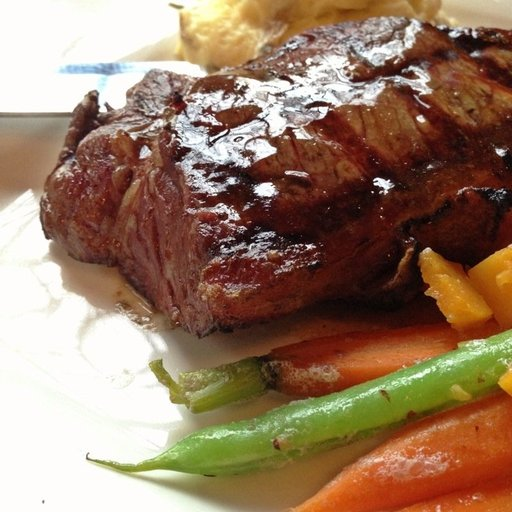

In [105]:
img

In [133]:
train_data = ImageDataGenerator(rescale=1/255.)
test_data = ImageDataGenerator(rescale=1/255.)
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

In [134]:
train_data = train_data.flow_from_directory(
    train_dir,target_size=(224,224),batch_size=32,class_mode="binary",seed=42)

Found 1500 images belonging to 2 classes.


In [135]:
test_data = test_data.flow_from_directory(
    test_dir,target_size=(224,224),batch_size=32,class_mode="binary",seed=42)

Found 500 images belonging to 2 classes.


In [136]:
model_one = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(8,activation="relu"),
    tf.keras.layers.Dense(8,activation="relu"),


    tf.keras.layers.Dense(1,activation="sigmoid"),
])

model_one.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │     1,204,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,204,313 (4.59 MB)

 Trainable params: 1,204,313 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

In [137]:
model_one.compile(loss="binary_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(),
                  metrics=["accuracy"])

In [148]:
history_one = model_one.fit(train_data,epochs=5,steps_per_epoch=len(train_data),
                            validation_data=test_data,
                            validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.4999 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.4974 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.4981 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.5098 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [149]:
loss,accuracy=model_one.evaluate(test_data)
print("Loss: ",loss)
print("Accuracy: ",accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.4987 - loss: 0.6932
Loss:  0.6931483745574951
Accuracy:  0.5


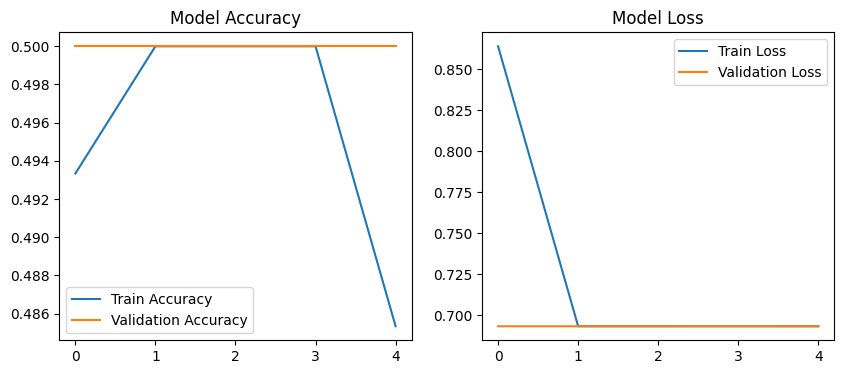

In [147]:
#plot accuracy and loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_one.history['accuracy'],label="Train Accuracy")
plt.plot(history_one.history['val_accuracy'],label="Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.subplot(1,2,2)
plt.plot(history_one.history['loss'],label="Train Loss")
plt.plot(history_one.history['val_loss'],label="Validation Loss")
plt.legend()
plt.title('Model Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


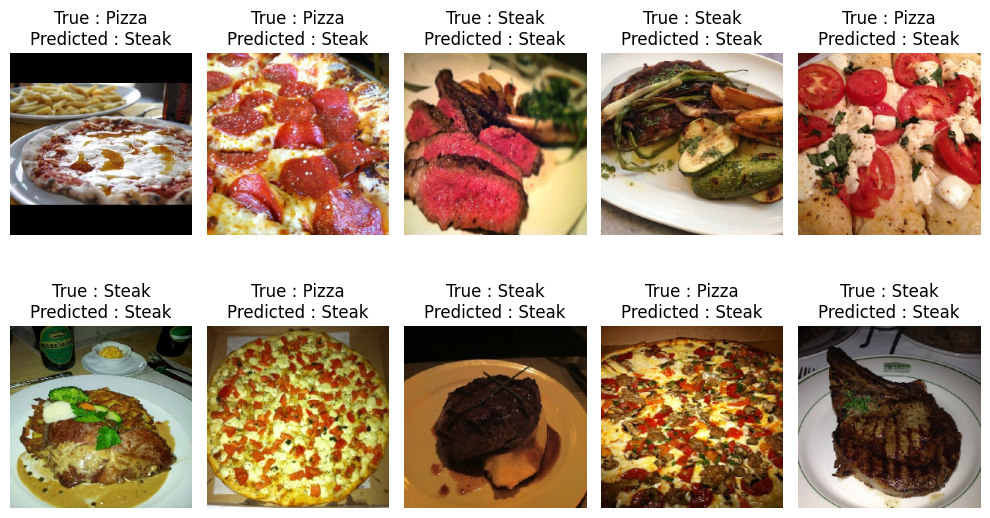

In [142]:
images,labels = next(test_data)
predictions = model_one.predict(images)
plt.figure(figsize=(10,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i])
  true_label="Pizza" if labels[i] == 0 else "Steak"
  pred_label= "Pizza" if predictions[i] < 0.5 else "Steak"
  plt.title(f"True : {true_label}\nPredicted : {pred_label}")
  plt.axis('off')
plt.tight_layout()
plt.show()

Saving pizza2.jpg to pizza2 (2).jpg
File Uploaded : pizza2 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction:  Steak
Confidence:  80.737465 %


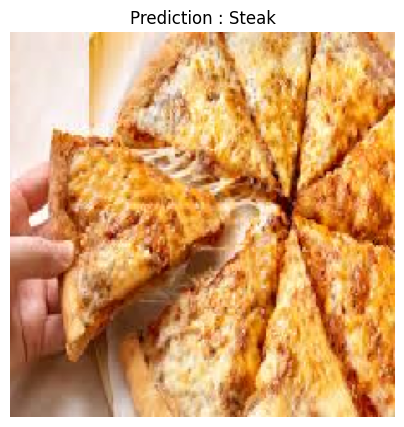

In [132]:
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  img_path=fn
  print("File Uploaded :", img_path)
  img=image.load_img(img_path,target_size=(224,224))
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)/255.0

  predict=model_one.predict(img_array)[0][0]
  label="Pizza" if predict < 0.5 else "Steak"
  print("Prediction: ",label)
  print("Confidence: ",100*(1-predict) if predict < 0.5 else 100*predict,"%")

  plt.figure(figsize=(5,5))
  plt.title(f"Prediction : {label}")
  plt.axis("off")
  plt.imshow(img)
  plt.show()

In [146]:
from tensorflow.keras.utils import load_img,img_to_array
img_sample = load_img("/content/sample_data/pizza_sam.jpg",target_size=(224,224))
img_sample=img_to_array(img_sample)
img_sample=img_sample/255
prediction=model_one.predict(tf.expand_dims(img_sample,axis=0))
class_names=["pizza","steak"]
predict_class=class_names[int(tf.round(prediction[0][0]))]
print("Image Entered by you is likely a", predict_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
Image Entered by you is likely a steak
